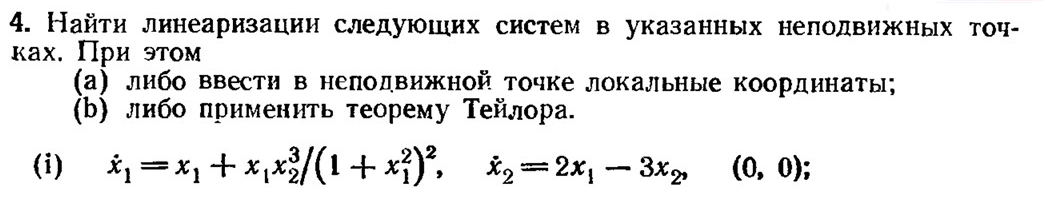

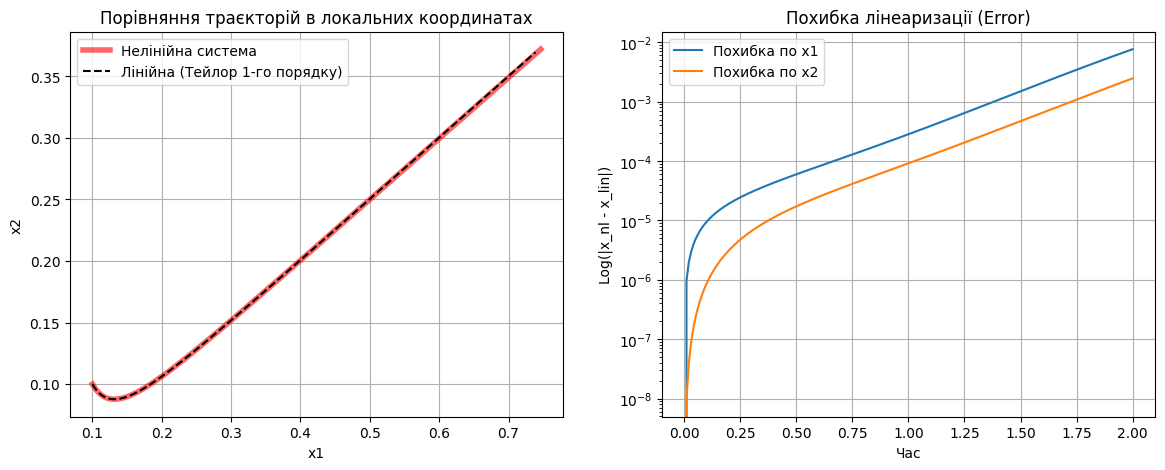

Матриця Якобі (обчислена через Autograd/Тейлор):
[[ 1.  0.]
 [ 2. -3.]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Системи рівнянь
def nonlinear_system(state, t):
    x1, x2 = state
    term_nonlinear = (x1 * x2**3) / ((1 + x1**2)**2)
    return [x1 + term_nonlinear, 2*x1 - 3*x2]

def linear_system(state, t):
    x1, x2 = state
    return [1*x1, 2*x1 - 3*x2]

# Час та початкові умови (дуже малі, локальні координати)
t = np.linspace(0, 2, 200)
x0 = [0.1, 0.1] # Відхилення 0.1 від рівноваги

# Інтегрування
sol_nl = odeint(nonlinear_system, x0, t)
sol_lin = odeint(linear_system, x0, t)

# Візуалізація
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(sol_nl[:, 0], sol_nl[:, 1], 'r', lw=4, alpha=0.6, label='Нелінійна система')
ax[0].plot(sol_lin[:, 0], sol_lin[:, 1], 'k--', label='Лінійна (Тейлор 1-го порядку)')
ax[0].set_title("Порівняння траєкторій в локальних координатах")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")
ax[0].legend()
ax[0].grid()

# 2. Графік похибки (Різниця між розв'язками)
error = np.abs(sol_nl - sol_lin)
ax[1].plot(t, error[:, 0], label='Похибка по x1')
ax[1].plot(t, error[:, 1], label='Похибка по x2')
ax[1].set_title("Похибка лінеаризації (Error)")
ax[1].set_yscale('log') # Логарифмічна шкала, щоб побачити малі значення
ax[1].set_xlabel("Час")
ax[1].set_ylabel("Log(|x_nl - x_lin|)")
ax[1].legend()
ax[1].grid()

plt.show()

# Виведення матриці Якобі кодом для перевірки
import torch
def get_jacobian_neural():
    # Емуляція знаходження градієнта в точці 0 за допомогою PyTorch (Autograd)
    # Це чисельний аналог Теореми Тейлора
    x1 = torch.tensor([0.0], requires_grad=True)
    x2 = torch.tensor([0.0], requires_grad=True)

    # Функції
    f1 = x1 + (x1 * x2**3) / ((1 + x1**2)**2)
    f2 = 2*x1 - 3*x2

    # Обчислюємо похідні (df/dx)
    f1.backward(retain_graph=True)
    j11 = x1.grad.item() # df1/dx1
    j12 = x2.grad.item() # df1/dx2

    # Скидаємо градієнти для другої функції
    x1.grad.zero_()
    x2.grad.zero_()

    f2.backward()
    j21 = x1.grad.item() # df2/dx1
    j22 = x2.grad.item() # df2/dx2

    return [[j11, j12], [j21, j22]]

print("Матриця Якобі (обчислена через Autograd/Тейлор):")
print(np.array(get_jacobian_neural()))